# GBDT для задачи Traffic & Mobility с использованием геометрий

В этом ноутбуке показан пример использования **Gradient Boosted Decision Trees (GBDT)** для градостроительной задачи класса **Traffic & Mobility**.

## Идея задачи

Мы используем реальные геоданные Санкт‑Петербурга из OpenStreetMap и строим модель, которая прогнозирует для каждого сегмента уличной сети условный показатель:

> **traffic_load_score** — прокси транспортной нагрузки / мобильностной важности сегмента дороги.

Это не прямые данные с датчиков трафика. Это учебная целевая переменная, построенная на основе реальных геометрий и городской структуры:
- типа дороги,
- длины сегмента,
- центральности в дорожном графе,
- плотности перекрёстков вокруг,
- близости к остановкам общественного транспорта,
- близости к POI,
- близости к станциям метро,
- геометрических признаков самой линии дороги.

Такой подход полезен, когда реальных датчиков трафика нет или они покрывают город неполностью.

## Что такое GBDT

**GBDT** — это семейство моделей, которые последовательно строят ансамбль решающих деревьев. Каждое следующее дерево исправляет ошибки предыдущих.

В этом примере используется `HistGradientBoostingRegressor` из `scikit-learn`.

Модель получает на вход табличные признаки, извлечённые из геометрий дорог и окружения, а на выходе прогнозирует показатель транспортной нагрузки.

## Установка библиотек

Если библиотеки ещё не установлены, раскомментируйте и выполните следующую ячейку.

In [ ]:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.9 MB/s eta 0:00:00


## Импорты и настройки

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import Point
from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

ox.settings.use_cache = True
ox.settings.log_console = False

PLACE = "Saint Petersburg, Russia"

# Для быстрых экспериментов можно поставить True.
# Тогда будет загружена не вся территория города, а центральная зона вокруг Дворцовой площади.
FAST_MODE = True

CENTER_POINT = (59.9386, 30.3141)  # lat, lon
DIST_METERS = 4500

LOCAL_CRS = "EPSG:32636"  # UTM zone 36N, метрическая проекция для Санкт-Петербурга
RANDOM_STATE = 42

## 1. Загрузка реальной дорожной сети Санкт‑Петербурга из OSM

Загрузим граф дорог. В `FAST_MODE=True` используется центральная часть города, чтобы пример выполнялся быстрее.

In [ ]:
if FAST_MODE:
    G = ox.graph_from_point(
        CENTER_POINT,
        dist=DIST_METERS,
        network_type="drive",
        simplify=True
    )
else:
    G = ox.graph_from_place(
        PLACE,
        network_type="drive",
        simplify=True
    )

G = ox.project_graph(G, to_crs=LOCAL_CRS)

nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
edges = edges.reset_index()
nodes = nodes.reset_index()

print("Узлы:", len(nodes))
print("Сегменты дорог:", len(edges))
edges.head()

Узлы: 3305
Сегменты дорог: 6778


,u,v,key,osmid,highway,lanes,maxspeed,oneway,reversed,length,name,geometry,junction,bridge,width,tunnel,access,ref
0,219811,1832085962,0,33997784,primary_link,2,RU:urban,False,False,27.905147,NaN,"LINESTRING (351066.086 6643191.309, 351091.28 ...",NaN,NaN,NaN,NaN,NaN,NaN
1,1832085962,219811,0,33997784,primary_link,2,RU:urban,False,True,27.905147,NaN,"LINESTRING (351091.28 6643179.103, 351066.086 ...",NaN,NaN,NaN,NaN,NaN,NaN
2,1832085962,10608755,0,"[309153673, 309915519]",primary,"[3, 4]",RU:urban,True,False,162.453682,Лиговский проспект,"LINESTRING (351091.28 6643179.103, 351097.938 ...",NaN,NaN,NaN,NaN,NaN,NaN
3,219812,249890545,0,4459876,primary,2,RU:urban,True,False,33.758153,Воздухоплавательная улица,"LINESTRING (351193.111 6643457.124, 351207.112...",NaN,NaN,NaN,NaN,NaN,NaN
4,219812,219811,0,"[387048069, 901225702]",primary,3,RU:urban,True,False,294.003362,Лиговский проспект,"LINESTRING (351193.111 6643457.124, 351170.858...",NaN,NaN,NaN,NaN,NaN,NaN


## 2. Подготовка геометрических признаков сегментов дорог

GBDT не умеет напрямую работать со столбцом `geometry`, поэтому мы извлечём из геометрии числовые признаки.

Для дорожного сегмента `LineString` полезны:
- длина,
- извилистость,
- направление,
- координаты центра,
- расстояние между началом и концом,
- тип дороги.

In [ ]:
roads = edges.copy()

roads = gpd.GeoDataFrame(roads, geometry="geometry", crs=LOCAL_CRS)

roads["length_m"] = roads.geometry.length
roads["centroid"] = roads.geometry.centroid
roads["x"] = roads["centroid"].x
roads["y"] = roads["centroid"].y

def endpoint_distance(geom):
    if geom is None or geom.is_empty:
        return np.nan
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
    else:
        coords = list(list(geom.geoms)[0].coords)
    p1 = Point(coords[0])
    p2 = Point(coords[-1])
    return p1.distance(p2)

roads["endpoint_dist_m"] = roads.geometry.apply(endpoint_distance)
roads["curviness"] = roads["length_m"] / roads["endpoint_dist_m"].replace(0, np.nan)
roads["curviness"] = roads["curviness"].replace([np.inf, -np.inf], np.nan).fillna(1.0)

def bearing_deg(geom):
    if geom is None or geom.is_empty:
        return np.nan
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
    else:
        coords = list(list(geom.geoms)[0].coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
    return (angle + 360) % 360

roads["bearing_deg"] = roads.geometry.apply(bearing_deg)
roads["bearing_sin"] = np.sin(np.deg2rad(roads["bearing_deg"]))
roads["bearing_cos"] = np.cos(np.deg2rad(roads["bearing_deg"]))

roads["highway_type"] = roads["highway"].apply(lambda v: v[0] if isinstance(v, list) else v).astype(str)

roads[["highway_type", "length_m", "curviness", "bearing_deg", "x", "y", "geometry"]].head()

,highway_type,length_m,curviness,bearing_deg,x,y,geometry
0,primary_link,27.995450,1.000000,334.149373,351078.683356,6.643185e+06,"LINESTRING (351066.086 6643191.309, 351091.28 ..."
1,primary_link,27.995450,1.000000,154.149373,351078.683356,6.643185e+06,"LINESTRING (351091.28 6643179.103, 351066.086 ..."
2,primary,162.789612,1.000025,64.711859,351126.240934,6.643253e+06,"LINESTRING (351091.28 6643179.103, 351097.938 ..."
3,primary,33.830822,1.000000,294.446244,351200.111450,6.643442e+06,"LINESTRING (351193.111 6643457.124, 351207.112..."
4,primary,294.612932,1.000024,244.458241,351129.642397,6.643324e+06,"LINESTRING (351193.111 6643457.124, 351170.858..."


## 3. Загрузка POI, остановок и станций метро

Для задачи Traffic & Mobility важен не только сам сегмент дороги, но и его городское окружение:
- близость остановок,
- близость метро,
- концентрация сервисов,
- плотность перекрёстков.

Загрузим это из OSM.

In [ ]:
if FAST_MODE:
    bbox = ox.utils_geo.bbox_from_point(CENTER_POINT, dist=DIST_METERS)
    polygon_wgs = ox.utils_geo.bbox_to_poly(bbox)

    tags_poi = {
        "amenity": True,
        "shop": True,
        "office": True,
        "tourism": True
    }
    tags_transit = {
        "highway": "bus_stop",
        "public_transport": True,
        "railway": "station",
        "station": "subway"
    }
    poi = ox.features_from_polygon(polygon_wgs, tags_poi)
    transit = ox.features_from_polygon(polygon_wgs, tags_transit)
else:
    tags_poi = {
        "amenity": True,
        "shop": True,
        "office": True,
        "tourism": True
    }
    tags_transit = {
        "highway": "bus_stop",
        "public_transport": True,
        "railway": "station",
        "station": "subway"
    }
    poi = ox.features_from_place(PLACE, tags_poi)
    transit = ox.features_from_place(PLACE, tags_transit)

poi = poi.reset_index()
transit = transit.reset_index()

poi = gpd.GeoDataFrame(poi, geometry="geometry", crs="EPSG:4326").to_crs(LOCAL_CRS)
transit = gpd.GeoDataFrame(transit, geometry="geometry", crs="EPSG:4326").to_crs(LOCAL_CRS)

poi_points = poi.copy()
poi_points["geometry"] = poi_points.geometry.centroid
poi_points = poi_points[poi_points.geometry.notna() & ~poi_points.geometry.is_empty]

transit_points = transit.copy()
transit_points["geometry"] = transit_points.geometry.centroid
transit_points = transit_points[transit_points.geometry.notna() & ~transit_points.geometry.is_empty]

metro_mask = transit_points.astype(str).apply(
    lambda row: ("subway" in " ".join(row.values).lower()) or ("metro" in " ".join(row.values).lower()),
    axis=1
)
metro_points = transit_points[metro_mask].copy()

print("POI:", len(poi_points))
print("Транспортные точки:", len(transit_points))
print("Метро / subway-like:", len(metro_points))

POI: 39630
Транспортные точки: 2311
Метро / subway-like: 34


## 4. Пространственные признаки окружения дороги

Создадим функции для:
- расстояния до ближайшего объекта,
- количества объектов в радиусе.

Это типичный способ использовать геометрию в GBDT: не передавать линию дороги напрямую, а считать на её основе признаки.

In [ ]:
def nearest_distance(source_gdf, target_gdf, source_geom_col="centroid"):
    """Расстояние от каждого объекта source до ближайшего объекта target в метрах."""
    if len(target_gdf) == 0:
        return np.full(len(source_gdf), np.nan)

    source_coords = np.vstack([
        source_gdf[source_geom_col].x.values,
        source_gdf[source_geom_col].y.values
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x.values,
        target_gdf.geometry.y.values
    ]).T

    tree = BallTree(target_coords, metric="euclidean")
    dist, _ = tree.query(source_coords, k=1)
    return dist[:, 0]


def count_within_radius(source_gdf, target_gdf, radius_m, source_geom_col="centroid"):
    """Количество target-объектов в радиусе radius_m от каждого source-объекта."""
    if len(target_gdf) == 0:
        return np.zeros(len(source_gdf), dtype=int)

    source_coords = np.vstack([
        source_gdf[source_geom_col].x.values,
        source_gdf[source_geom_col].y.values
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x.values,
        target_gdf.geometry.y.values
    ]).T

    tree = BallTree(target_coords, metric="euclidean")
    counts = tree.query_radius(source_coords, r=radius_m, count_only=True)
    return counts


roads["dist_to_nearest_poi_m"] = nearest_distance(roads, poi_points)
roads["poi_count_300m"] = count_within_radius(roads, poi_points, 300)
roads["poi_count_700m"] = count_within_radius(roads, poi_points, 700)

roads["dist_to_nearest_transit_m"] = nearest_distance(roads, transit_points)
roads["transit_count_300m"] = count_within_radius(roads, transit_points, 300)
roads["transit_count_700m"] = count_within_radius(roads, transit_points, 700)

roads["dist_to_nearest_metro_m"] = nearest_distance(roads, metro_points) if len(metro_points) else np.nan
roads["metro_count_1000m"] = count_within_radius(roads, metro_points, 1000) if len(metro_points) else 0

roads[[
    "length_m",
    "curviness",
    "poi_count_300m",
    "transit_count_300m",
    "dist_to_nearest_transit_m",
    "dist_to_nearest_metro_m"
]].head()

,length_m,curviness,poi_count_300m,transit_count_300m,dist_to_nearest_transit_m,dist_to_nearest_metro_m
0,27.995450,1.000000,15,4,41.663218,1716.905806
1,27.995450,1.000000,15,4,41.663218,1716.905806
2,162.789612,1.000025,17,4,123.039847,1635.152159
3,33.830822,1.000000,24,3,195.611819,1433.399331
4,294.612932,1.000024,23,5,184.900598,1570.293625


## 5. Признаки графа дорожной сети

Traffic & Mobility сильно зависит от положения дороги в сети:
- насколько сегмент центральный,
- сколько дорог сходится рядом,
- насколько он важен для кратчайших путей.

Для примера посчитаем степень узлов и приближённую betweenness centrality.

In [ ]:
degree_dict = dict(G.degree())
roads["u_degree"] = roads["u"].map(degree_dict)
roads["v_degree"] = roads["v"].map(degree_dict)
roads["mean_node_degree"] = roads[["u_degree", "v_degree"]].mean(axis=1)

k_sample = min(500, len(G.nodes))
node_bc = nx.betweenness_centrality(G, k=k_sample, weight="length", seed=RANDOM_STATE)

roads["u_betweenness"] = roads["u"].map(node_bc)
roads["v_betweenness"] = roads["v"].map(node_bc)
roads["mean_betweenness"] = roads[["u_betweenness", "v_betweenness"]].mean(axis=1)

roads[["mean_node_degree", "mean_betweenness"]].describe()

,mean_node_degree,mean_betweenness
count,6778.000000,6778.000000
mean,4.482296,0.012250
std,1.083389,0.013620
min,1.500000,0.000000
25%,3.500000,0.002876
50%,4.000000,0.007774
75%,5.000000,0.016413
max,8.500000,0.102644


## 6. Целевая переменная: прокси транспортной нагрузки

В реальном проекте целевой переменной могли бы быть:
- средняя скорость по GPS-трекам,
- интенсивность движения,
- задержка транспорта,
- количество поездок,
- число ДТП,
- загруженность по датчикам.

В этом учебном примере мы создадим `traffic_load_score` как прокси на основе реальной городской структуры. Это позволит показать полный ML-пайплайн без закрытых данных.

In [ ]:
road_weight = {
    "motorway": 1.00,
    "trunk": 0.95,
    "primary": 0.90,
    "secondary": 0.75,
    "tertiary": 0.60,
    "unclassified": 0.40,
    "residential": 0.35,
    "service": 0.20,
    "living_street": 0.15,
}

roads["road_class_weight"] = roads["highway_type"].map(road_weight).fillna(0.30)

def minmax(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    s = s.fillna(s.median())
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

roads["n_length"] = minmax(roads["length_m"])
roads["n_poi"] = minmax(roads["poi_count_700m"])
roads["n_transit"] = minmax(roads["transit_count_700m"])
roads["n_metro"] = minmax(roads["metro_count_1000m"])
roads["n_degree"] = minmax(roads["mean_node_degree"])
roads["n_betweenness"] = minmax(roads["mean_betweenness"])

roads["n_transit_distance"] = 1 - minmax(roads["dist_to_nearest_transit_m"])
roads["n_metro_distance"] = 1 - minmax(roads["dist_to_nearest_metro_m"])

rng = np.random.default_rng(RANDOM_STATE)
noise = rng.normal(0, 0.04, size=len(roads))

roads["traffic_load_score"] = (
    0.30 * roads["road_class_weight"] +
    0.15 * roads["n_betweenness"] +
    0.12 * roads["n_degree"] +
    0.12 * roads["n_poi"] +
    0.10 * roads["n_transit"] +
    0.08 * roads["n_transit_distance"] +
    0.07 * roads["n_metro_distance"] +
    0.04 * roads["n_length"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)

roads[["highway_type", "traffic_load_score", "road_class_weight", "n_betweenness", "n_poi", "n_transit"]].head()

,highway_type,traffic_load_score,road_class_weight,n_betweenness,n_poi,n_transit
0,primary_link,0.240542,0.3,0.004354,0.019452,0.077670
1,primary_link,0.186754,0.3,0.004354,0.019452,0.077670
2,primary,0.440061,0.9,0.001451,0.025829,0.116505
3,primary,0.472743,0.9,0.043785,0.047194,0.155340
4,primary,0.344074,0.9,0.022884,0.029656,0.126214


## 7. Подготовка признаков для GBDT

Используем:
- геометрические признаки линии,
- координаты центроида,
- признаки окружения,
- признаки графа,
- категориальный тип дороги через one-hot encoding.

Важно: сам столбец `geometry` в модель не передаём.

In [ ]:
numeric_features = [
    "length_m",
    "endpoint_dist_m",
    "curviness",
    "bearing_sin",
    "bearing_cos",
    "x",
    "y",
    "dist_to_nearest_poi_m",
    "poi_count_300m",
    "poi_count_700m",
    "dist_to_nearest_transit_m",
    "transit_count_300m",
    "transit_count_700m",
    "dist_to_nearest_metro_m",
    "metro_count_1000m",
    "mean_node_degree",
    "mean_betweenness",
]

model_df = roads[numeric_features + ["highway_type", "traffic_load_score", "geometry"]].copy()

for col in numeric_features:
    model_df[col] = model_df[col].replace([np.inf, -np.inf], np.nan)
    model_df[col] = model_df[col].fillna(model_df[col].median())

X = pd.get_dummies(model_df[numeric_features + ["highway_type"]], columns=["highway_type"], dummy_na=True)
y = model_df["traffic_load_score"]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, model_df.index, test_size=0.25, random_state=RANDOM_STATE
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (5083, 27)
Размер тестовой выборки: (1695, 27)


## 8. Обучение GBDT-модели

In [ ]:
model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print("Train MAE:", round(mean_absolute_error(y_train, pred_train), 4))
print("Test MAE:", round(mean_absolute_error(y_test, pred_test), 4))
print("Train R2:", round(r2_score(y_train, pred_train), 4))
print("Test R2:", round(r2_score(y_test, pred_test), 4))

Train MAE: 0.0212
Test MAE: 0.0337
Train R2: 0.9292
Test R2: 0.8183


## 9. Важность признаков

Для `HistGradientBoostingRegressor` удобно использовать permutation importance.
Она показывает, насколько ухудшается качество модели при случайном перемешивании каждого признака.

In [ ]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
18,highway_type_primary,0.014732
21,highway_type_secondary,0.012658
16,mean_betweenness,0.009248
20,highway_type_residential,0.008025
12,transit_count_700m,0.007217
23,highway_type_tertiary,0.006737
9,poi_count_700m,0.005747
15,mean_node_degree,0.004229
13,dist_to_nearest_metro_m,0.001662
10,dist_to_nearest_transit_m,0.001399


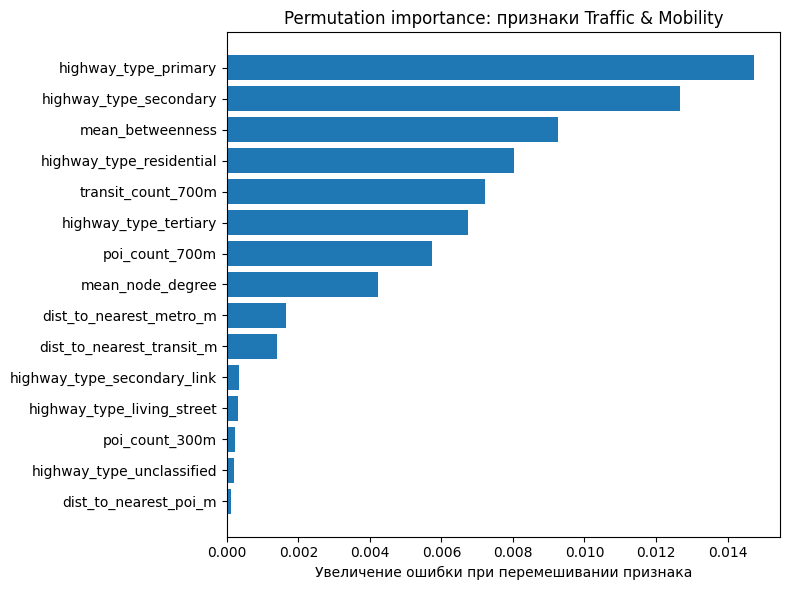

In [ ]:
top = importance.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.title("Permutation importance: признаки Traffic & Mobility")
plt.xlabel("Увеличение ошибки при перемешивании признака")
plt.tight_layout()
plt.show()

## 10. Карта прогноза транспортной нагрузки

Построим карту, где цвет сегмента соответствует предсказанному `traffic_load_score`.

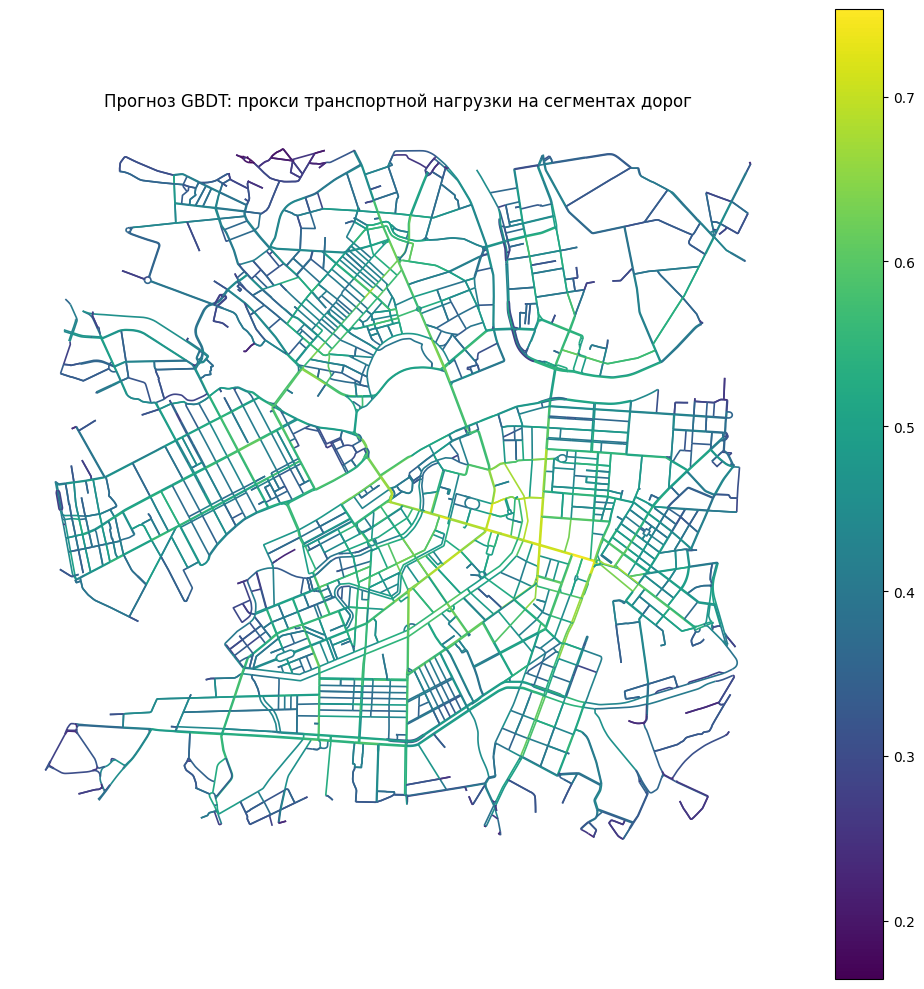

In [ ]:
roads_result = roads.copy()
roads_result["predicted_traffic_load"] = model.predict(X)

fig, ax = plt.subplots(figsize=(10, 10))
roads_result.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.2,
    legend=True,
    cmap="viridis"
)
ax.set_title("Прогноз GBDT: прокси транспортной нагрузки на сегментах дорог")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 11. Анализ ошибок

In [ ]:
test_result = model_df.loc[idx_test].copy()
test_result["y_true"] = y_test.values
test_result["y_pred"] = pred_test
test_result["abs_error"] = np.abs(test_result["y_true"] - test_result["y_pred"])

error_by_road_type = (
    test_result
    .groupby("highway_type")
    .agg(
        count=("abs_error", "size"),
        mae=("abs_error", "mean"),
        mean_true=("y_true", "mean"),
        mean_pred=("y_pred", "mean")
    )
    .sort_values("mae", ascending=False)
)

error_by_road_type.head(15)

,count,mae,mean_true,mean_pred
highway_type,,,,
secondary_link,25,0.044886,0.298737,0.316638
primary,192,0.036498,0.579369,0.580675
tertiary_link,18,0.034331,0.319460,0.316076
residential,609,0.033712,0.379714,0.379027
tertiary,440,0.033675,0.466114,0.463406
unclassified,86,0.032880,0.368949,0.371956
secondary,304,0.031661,0.502305,0.503638
primary_link,12,0.031160,0.398490,0.428925
living_street,9,0.027807,0.329515,0.346704


## 12. Как это применить к реальным данным Traffic & Mobility

В реальном проекте вместо синтетического `traffic_load_score` можно использовать:

1. **GPS-треки транспорта**
   - средняя скорость на сегменте,
   - задержка относительно free-flow speed,
   - число поездок через сегмент.

2. **Данные общественного транспорта**
   - фактическое время прохождения перегона,
   - задержки автобусов/трамваев,
   - интервалы движения.

3. **Датчики и камеры**
   - интенсивность потока,
   - occupancy,
   - средняя скорость,
   - очередь на перекрёстке.

4. **ДТП и безопасность**
   - вероятность ДТП,
   - число конфликтных точек,
   - риск для пешеходов и велосипедистов.

Геометрические признаки при этом остаются теми же:
- длина сегмента,
- извилистость,
- направление,
- класс дороги,
- плотность пересечений,
- близость к остановкам,
- близость к центрам притяжения,
- центральность в графе,
- пространственная позиция.